In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df_train=pd.read_csv('../../data/house_price/train.csv')
df_test=pd.read_csv('../../data/house_price/test.csv')
print(df_train.shape)
df_train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


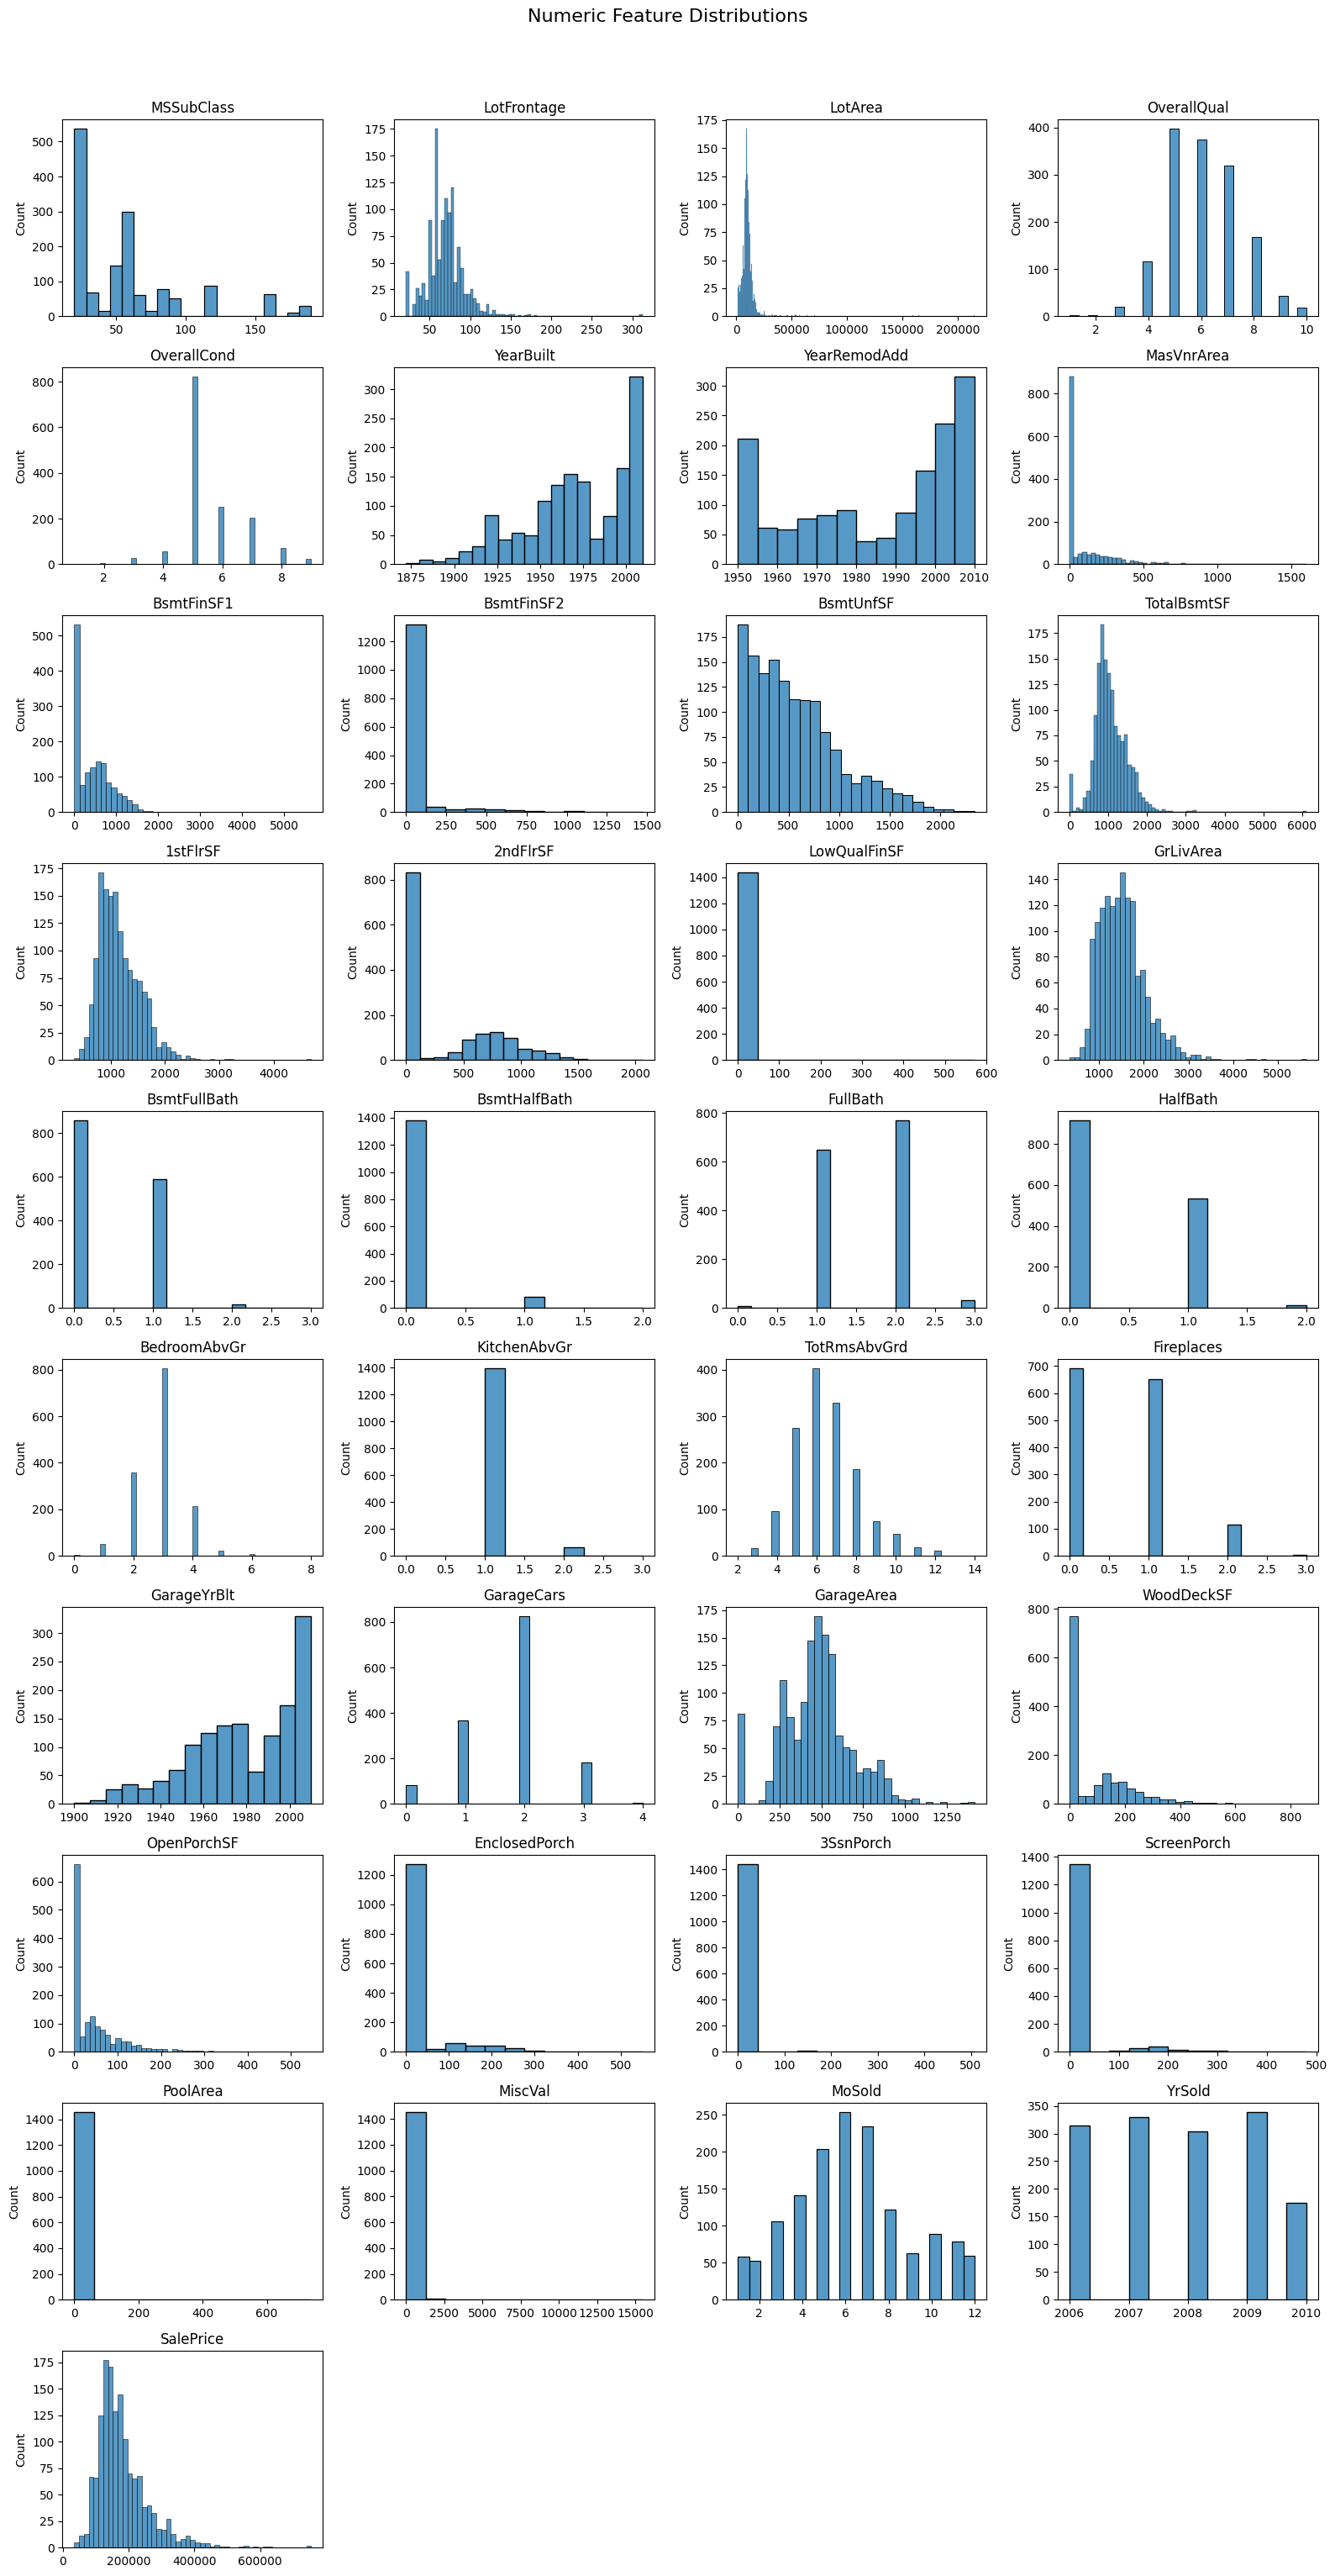

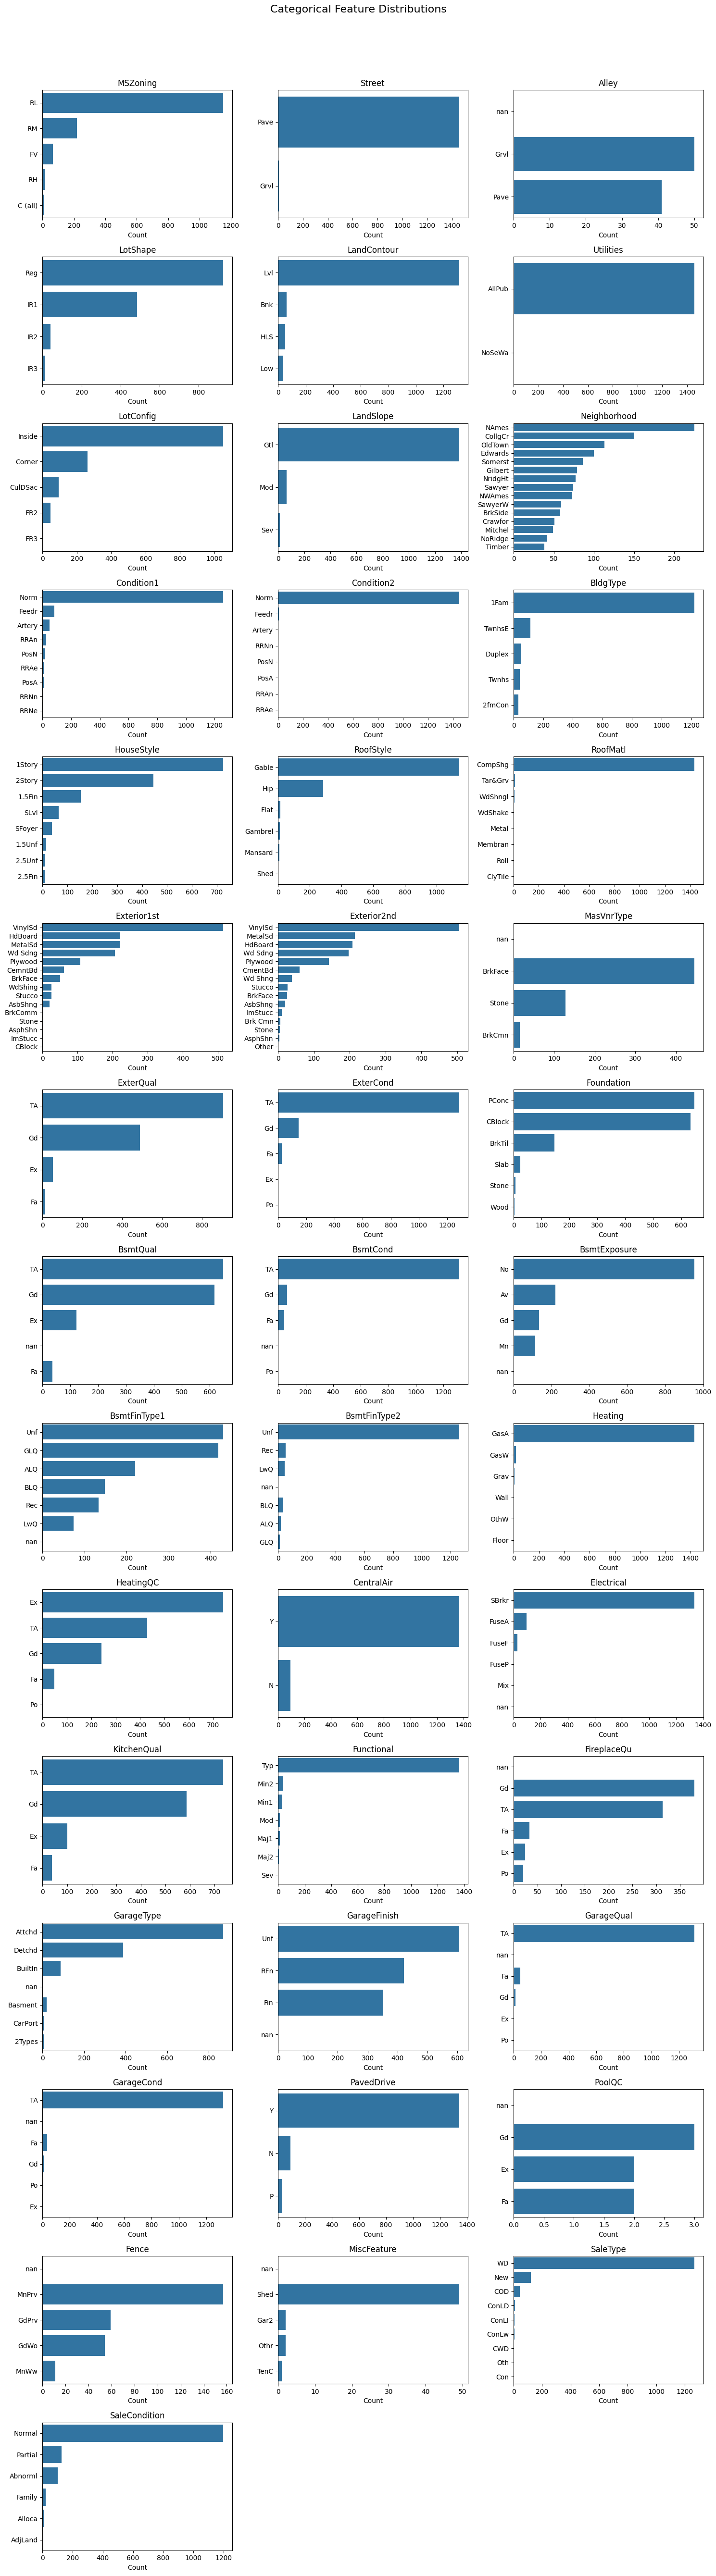

In [10]:
numeric_features = df_train.select_dtypes(include=[np.number]).columns.drop('Id', errors='ignore')
categorical_features = df_train.select_dtypes(include=['object']).columns

def plot_numeric_distributions(df, columns, cols_per_row=4):
    rows = int(np.ceil(len(columns) / cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(df[col].dropna(), ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle('Numeric Feature Distributions', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_categorical_distributions(df, columns, cols_per_row=3, top_n=15):
    rows = int(np.ceil(len(columns) / cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        order = df[col].value_counts(dropna=False).head(top_n).index
        sns.countplot(data=df, y=col, order=order, ax=ax)
        ax.set_title(col)
        ax.set_xlabel('Count')
        ax.set_ylabel('')

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle('Categorical Feature Distributions', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_numeric_distributions(df_train, numeric_features)
plot_categorical_distributions(df_train, categorical_features)


##  Distribution observations and TODOs

### Features with obvious outliers

- `GrLivArea` has two very suspicious high-area but low-price samples:
  - `Id=1299`: `GrLivArea=5642`, `SalePrice=160000`
  - `Id=524`: `GrLivArea=4676`, `SalePrice=184750`
- These points can strongly distort the relationship between living area and sale price. Consider removing samples where `GrLivArea > 4000` and `SalePrice` is relatively low.

### Skewed numeric features

- `LotArea`: highly right-skewed, with extreme maximum values far above the median.
- `LotFrontage`: has large outliers and many missing values.
- `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`, `GarageArea`, `MasVnrArea`: contain large upper-tail values that may need further inspection with scatter plots against `SalePrice`.
- Suggested handling: use `np.log1p()` for strongly right-skewed continuous features, or apply capping/winsorization if extreme values are likely to hurt model stability.

### Zero-inflated features

- Many samples have zero values for `PoolArea`, `MiscVal`, `3SsnPorch`, `LowQualFinSF`, `ScreenPorch`, `EnclosedPorch`, and `BsmtFinSF2`.
- These zeros usually mean the house does not have that feature, not necessarily missing data.
- Suggested handling: create binary indicators such as `HasPool`, `HasMiscFeature`, `Has3SsnPorch`, `HasScreenPorch`, etc.

### Target variable

- `SalePrice` is right-skewed and has high-price outliers.
- Suggested handling: model `np.log1p(SalePrice)` instead of raw `SalePrice`.

### Rare categorical levels

- `Utilities` has almost no variation (`NoSeWa` appears only once), so it may provide little predictive value.
- `Condition2`, `RoofMatl`, `Heating`, `PoolQC`, `MiscFeature`, `SaleType`, and `SaleCondition` contain rare categories.
- Suggested handling: group very rare categories into `Other`, or drop near-constant categorical features such as `Utilities`.


## Data cleaning